# Project: Monthly Electricity Bill Prediction System

## Install Project dependencies

In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 20.5 MB/s eta 0:00:04
   --- ------------------------------------ 6.0/69.5 MB 23.0 MB/s eta 0:00:03
   ------ --------------------------------- 11.5/69.5 MB 24.6 MB/s eta 0:00:03
   --------- ------------------------------ 17.0/69.5 MB 25.1 MB/s eta 0:00:03
   ------------ --------------------------- 22.3/69.5 MB 25.1 MB/s eta 0:00:02
   ---------------- ----------------------- 28.0/69.5 MB 25.6 MB/s eta 0:00:02
   ------------------- -------------------- 34.1/69.5 MB 26.2 MB/s eta 0:00:02
   ----------------------- ---------------- 40.1/69.5 MB 26.7 MB/s eta 0:00:02
   -------------------------- ------------- 45.6/69.5 MB 26.4 MB/s eta 0:00:01
   ---------------------------- ----------- 50.3/69.5 MB 26.0 MB/s eta 0:00:01
   ------------------------------- -------- 55.3/69.5 MB 25.8 MB/s eta 0:00:01
   ---------------------------------- ----- 60.3/69.5 MB 25.5 M


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Project Dependencies

In [1]:
# Imported all the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

## Step 1 : Data Loading

In [ ]:
# Loaded the dataset

df = pd.read_csv("indian_household_electricity_bill_dataset.csv")

# Displayed the first five rows

df.head()

,State,Region,Season,Ambient_Temperature_C,Home_Type,Household_Size,Connection_Type,Sanctioned_Load_kW,Avg_BEE_Star_Rating,Has_Inverter_AC,...,Phase_Imbalance_Pct,Base_Monthly_kWh,Monthly_Billed_Units,Energy_Charge_INR,Fixed_Charge_INR,PPAC_Pct,PPAC_Charge_INR,Electricity_Duty_Pct,Electricity_Duty_INR,Total_Bill_INR
0,Karnataka,South,Monsoon,30.8,Row House,3,Single Phase,1,4.3,1,...,0.0,197.21,220.80,1305.00,95,29.4,383.67,9.0,160.53,1944.20
1,Gujarat,West,Winter,22.1,Independent House,1,Single Phase,2,3.2,0,...,0.0,48.87,76.18,194.37,230,34.9,67.83,12.0,59.06,551.26
2,Gujarat,West,Summer,22.4,Villa,2,Single Phase,3,3.9,0,...,0.0,146.12,160.81,507.50,345,34.9,177.12,5.7,58.69,1088.30
3,Punjab,North,Spring,25.7,Row House,5,Single Phase,1,1.2,0,...,0.0,243.98,270.87,0.00,110,27.4,0.00,6.7,7.37,117.37
4,Uttar Pradesh,North,Monsoon,30.9,Independent House,5,Three Phase,15,3.2,0,...,23.8,228.22,259.13,1037.24,1575,32.3,335.03,10.2,300.62,3247.89


## Step 2: Data Preprocessing

In [3]:
# Displayed the dataset information

print(df.info())

# Checked the shape of the dataset

print("Dataset Shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   State                        2000 non-null   str    
 1   Region                       2000 non-null   str    
 2   Season                       2000 non-null   str    
 3   Ambient_Temperature_C        2000 non-null   float64
 4   Home_Type                    2000 non-null   str    
 5   Household_Size               2000 non-null   int64  
 6   Connection_Type              2000 non-null   str    
 7   Sanctioned_Load_kW           2000 non-null   int64  
 8   Avg_BEE_Star_Rating          2000 non-null   float64
 9   Has_Inverter_AC              2000 non-null   int64  
 10  Num_Non_Inverter_Appliances  2000 non-null   int64  
 11  Num_Nonlinear_Loads          2000 non-null   int64  
 12  Wiring_Age_Years             2000 non-null   int64  
 13  Wiring_Condition             

In [4]:
# Checked for missing values

print("\nMissing Values:")
print(df.isnull().sum())

# Removed duplicate rows if any were present

df.drop_duplicates(inplace=True)




Missing Values:
State                          0
Region                         0
Season                         0
Ambient_Temperature_C          0
Home_Type                      0
Household_Size                 0
Connection_Type                0
Sanctioned_Load_kW             0
Avg_BEE_Star_Rating            0
Has_Inverter_AC                0
Num_Non_Inverter_Appliances    0
Num_Nonlinear_Loads            0
Wiring_Age_Years               0
Wiring_Condition               0
Power_Factor                   0
Billing_Mode                   0
THD_Pct                        0
Phase_Imbalance_Pct            0
Base_Monthly_kWh               0
Monthly_Billed_Units           0
Energy_Charge_INR              0
Fixed_Charge_INR               0
PPAC_Pct                       0
PPAC_Charge_INR                0
Electricity_Duty_Pct           0
Electricity_Duty_INR           0
Total_Bill_INR                 0
dtype: int64


In [17]:
df_no_outliers = df.copy()

numerical_cols = df_no_outliers.select_dtypes(include=["int64", "float64"]).columns

# Removed outliers column by column
for col in numerical_cols:
    
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower_bound) &
        (df_no_outliers[col] <= upper_bound)
    ]

print("Original Shape :", df.shape)
print("After Removing Outliers :", df_no_outliers.shape)

Original Shape : (2000, 27)
After Removing Outliers : (1142, 27)


In [18]:
# Separated the input features and target variable

X = df_no_outliers.drop("Total_Bill_INR", axis=1)

y = df_no_outliers["Total_Bill_INR"]

# Identified categorical and numerical columns

categorical_columns = X.select_dtypes(include=["object","string"]).columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

# Encoded all categorical columns

encoder = OneHotEncoder()
scaler = StandardScaler()

numeric_transformer = Pipeline(steps=[
    ('scaler', scaler)
])

categorical_transformer = Pipeline(steps=[
    ('encoder', encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ])

preprocessor.fit(X)
X_transformed = preprocessor.transform(X)

print("\nData preprocessing completed successfully.")


Data preprocessing completed successfully.


## Step 3: Exploratory Data Analysis (EDA)

In [7]:
# Displayed descriptive statistics

df_no_outliers.describe()

,Ambient_Temperature_C,Household_Size,Sanctioned_Load_kW,Avg_BEE_Star_Rating,Has_Inverter_AC,Num_Non_Inverter_Appliances,Num_Nonlinear_Loads,Wiring_Age_Years,Power_Factor,THD_Pct,Phase_Imbalance_Pct,Base_Monthly_kWh,Monthly_Billed_Units,Energy_Charge_INR,Fixed_Charge_INR,PPAC_Pct,PPAC_Charge_INR,Electricity_Duty_Pct,Electricity_Duty_INR,Total_Bill_INR
count,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.0,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000,1142.000000
mean,29.590280,4.057793,2.758319,3.058056,0.504378,2.964098,8.021016,14.942207,0.855261,11.745867,0.0,213.663354,250.944142,854.166349,296.992119,27.158319,230.188363,9.836690,133.285797,1514.632601
std,7.611063,2.195563,1.453123,1.142779,0.500200,1.972983,4.299430,8.998013,0.080217,8.638315,0.0,123.826561,143.247226,734.561387,161.403499,7.009840,208.575276,2.797985,95.699087,1024.944620
min,9.800000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.720000,0.370000,0.0,28.620000,31.750000,0.000000,90.000000,15.000000,0.000000,5.000000,5.610000,98.010000
25%,25.125000,2.000000,2.000000,2.100000,0.000000,1.000000,4.000000,7.000000,0.785250,4.602500,0.0,113.110000,132.212500,224.130000,180.000000,21.200000,58.815000,7.400000,56.640000,651.380000
50%,29.400000,4.000000,3.000000,3.100000,1.000000,3.000000,8.000000,15.000000,0.856000,9.400000,0.0,202.490000,240.905000,690.035000,270.000000,27.050000,178.105000,9.700000,110.125000,1309.735000
75%,34.400000,6.000000,3.000000,4.000000,1.000000,5.000000,12.000000,23.000000,0.927000,17.430000,0.0,293.845000,345.305000,1338.772500,390.000000,33.200000,355.417500,12.200000,191.502500,2176.577500
max,48.000000,8.000000,5.000000,5.000000,1.000000,6.000000,15.000000,30.000000,0.990000,37.230000,0.0,661.490000,747.920000,3177.200000,650.000000,40.000000,931.080000,15.000000,427.910000,4501.540000


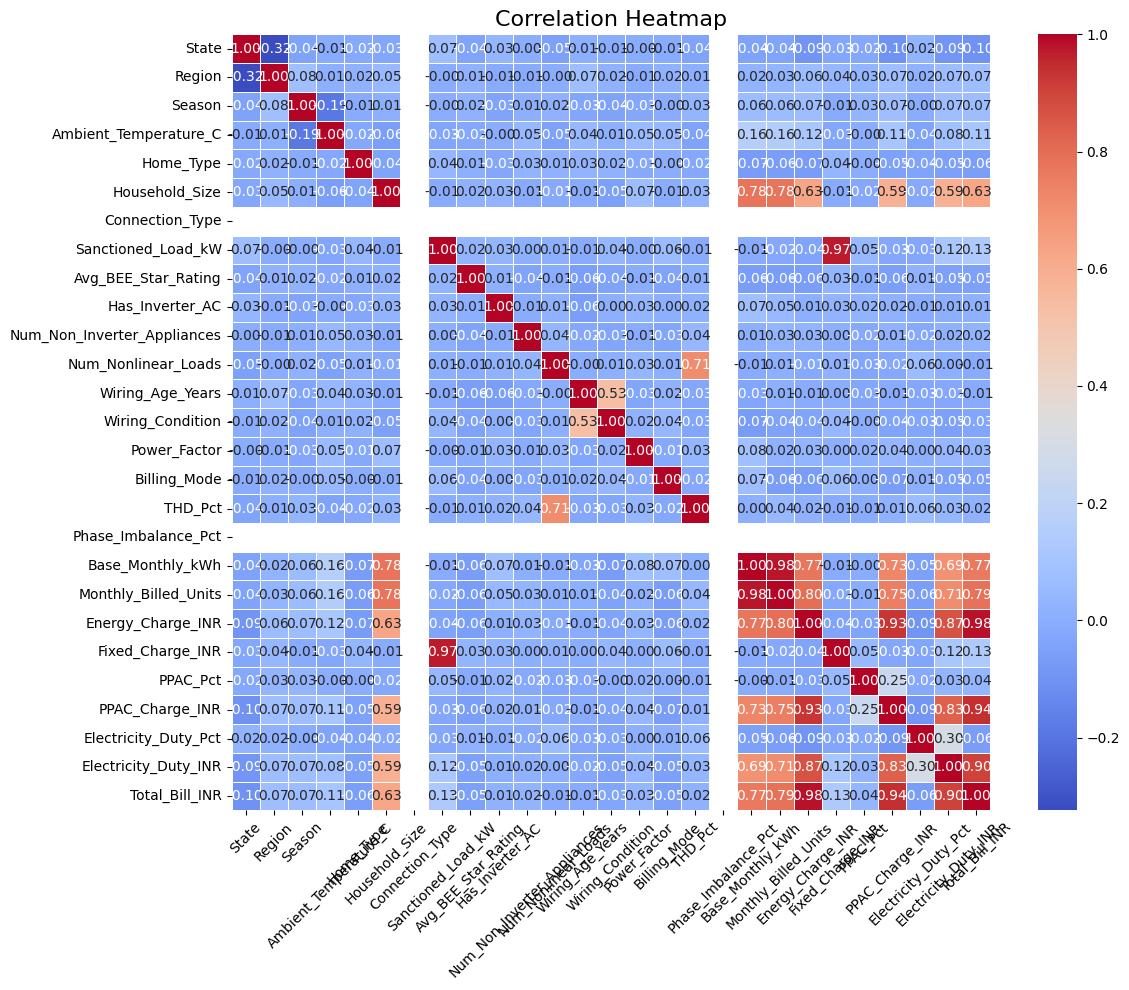

In [8]:
# Created a copy of the dataset
encoded_df = df_no_outliers.copy()

# Encoded categorical columns
label_encoder = LabelEncoder()

categorical_cols = encoded_df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    encoded_df[col] = label_encoder.fit_transform(encoded_df[col])

# Calculated correlation matrix
correlation_matrix = encoded_df.corr(numeric_only=False)

# Plotted the heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

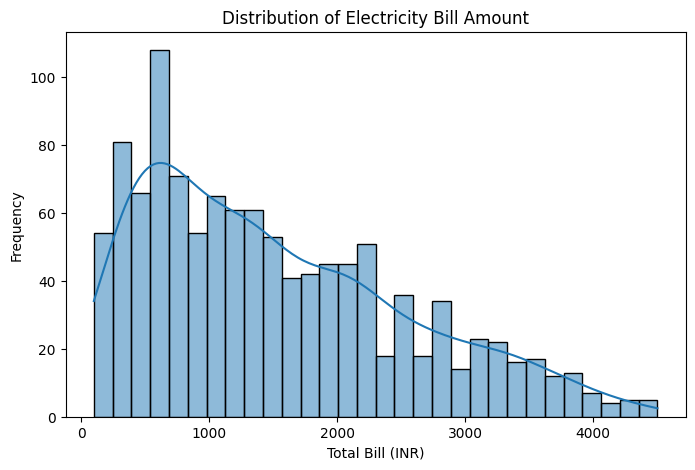

In [9]:
# Visualized the distribution of the target variable

plt.figure(figsize=(8,5))

sns.histplot(
    y,
    bins=30,
    kde=True
)

plt.title("Distribution of Electricity Bill Amount")
plt.xlabel("Total Bill (INR)")
plt.ylabel("Frequency")

plt.show()

In [10]:
# Displayed feature correlations with the target variable
numerical_df = df_no_outliers.select_dtypes(include=["int64", "float64"])

correlation = numerical_df.corr()["Total_Bill_INR"].sort_values(ascending=False)

print(correlation)

Total_Bill_INR                 1.000000
Energy_Charge_INR              0.980498
PPAC_Charge_INR                0.943046
Electricity_Duty_INR           0.901921
Monthly_Billed_Units           0.785353
Base_Monthly_kWh               0.765686
Household_Size                 0.625246
Fixed_Charge_INR               0.134442
Sanctioned_Load_kW             0.130797
Ambient_Temperature_C          0.108525
PPAC_Pct                       0.035681
Power_Factor                   0.033759
Num_Non_Inverter_Appliances    0.023192
THD_Pct                        0.018732
Has_Inverter_AC                0.013459
Wiring_Age_Years              -0.010398
Num_Nonlinear_Loads           -0.011570
Avg_BEE_Star_Rating           -0.054792
Electricity_Duty_Pct          -0.062548
Phase_Imbalance_Pct                 NaN
Name: Total_Bill_INR, dtype: float64


## Step 4: Model Training

In [19]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed,
    y,
    test_size=0.20,
    random_state=42
)

# Created the XGBoost regression model

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Trained the model

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## Step 5: Model Evaluation Using Scikit-learn Metrics

In [20]:
# Predicted the electricity bill for the testing data

y_pred = model.predict(X_test)

# Calculated evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Displayed the evaluation results

print("Model Evaluation Results")
print("----------------------------")
print(f"Mean Absolute Error : {mae:.2f}")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"Root Mean Squared Error : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Model Evaluation Results
----------------------------
Mean Absolute Error : 27.64
Mean Squared Error  : 1462.20
Root Mean Squared Error : 38.24
R² Score : 0.9983


## Step 6: Feature Importance

                              Feature  Importance
13             num__Energy_Charge_INR    0.838972
16               num__PPAC_Charge_INR    0.039425
25                  cat__State_Punjab    0.037869
18          num__Electricity_Duty_INR    0.028199
14              num__Fixed_Charge_INR    0.012084
12          num__Monthly_Billed_Units    0.008880
2             num__Sanctioned_Load_kW    0.008044
27              cat__State_Tamil Nadu    0.007246
28               cat__State_Telangana    0.005676
19                   cat__State_Delhi    0.004726
17          num__Electricity_Duty_Pct    0.003353
15                      num__PPAC_Pct    0.000783
23          cat__State_Madhya Pradesh    0.000733
45      cat__Wiring_Condition_Average    0.000361
29           cat__State_Uttar Pradesh    0.000357
20                 cat__State_Gujarat    0.000244
38                 cat__Season_Summer    0.000243
11              num__Base_Monthly_kWh    0.000213
24             cat__State_Maharashtra    0.000200


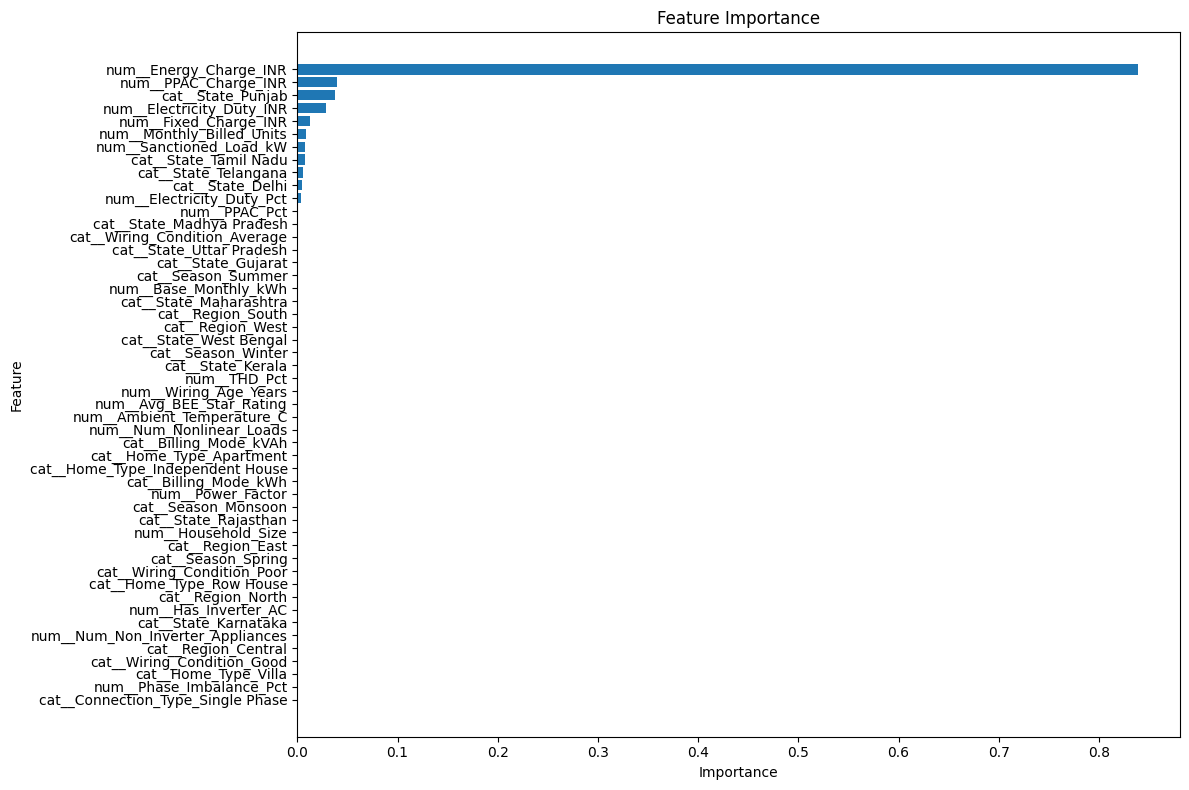

In [21]:
# Got feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Created feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(12,8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Step 7: Model Testing

In [22]:
# Tested the model using unseen testing samples

X_test_df = pd.DataFrame(X_test, columns=feature_names)

prediction = model.predict(X_test_df)

prediction_df = pd.DataFrame({
    "Predicted_Bill": prediction,
    "Actual_Bill": y_test.reset_index(drop=True)
})

print(prediction_df.head(10))



   Predicted_Bill  Actual_Bill
0      233.132568       236.94
1     1649.270508      1622.08
2     1332.957397      1334.78
3     2079.511475      2044.70
4     1319.735840      1274.77
5      801.336487       715.62
6      374.088196       368.61
7      826.400208       795.34
8      463.028503       449.71
9      591.101318       565.00
